In [1]:
# Section 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

In [2]:
# Section 2 — Paths & Load Data
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

ML_FEATURES_PATH = (
    PROCESSED_DATA_DIR /
    "customer_features_ml.parquet"
)

KMEANS_PATH = (
    PROCESSED_DATA_DIR /
    "customer_segments_kmeans.parquet"
)

ml_df = pd.read_parquet(ML_FEATURES_PATH)
kmeans_df = pd.read_parquet(KMEANS_PATH)

print("ML features:", ml_df.shape)
print("K-Means data:", kmeans_df.shape)

ML features: (5878, 11)
K-Means data: (5878, 17)


In [3]:
# Section 3 — ML Matrix
feature_columns = [
    "recency_days",
    "log_frequency",
    "log_monetary",
    "log_average_order_value",
    "log_avg_items_per_order",
    "log_unique_products",
    "purchase_span_days",
    "return_order_share",
    "return_value_share",
    "has_return"
]

X = ml_df[feature_columns].copy()

print("X shape:", X.shape)
print("Missing values:", X.isna().sum().sum())

X shape: (5878, 10)
Missing values: 0


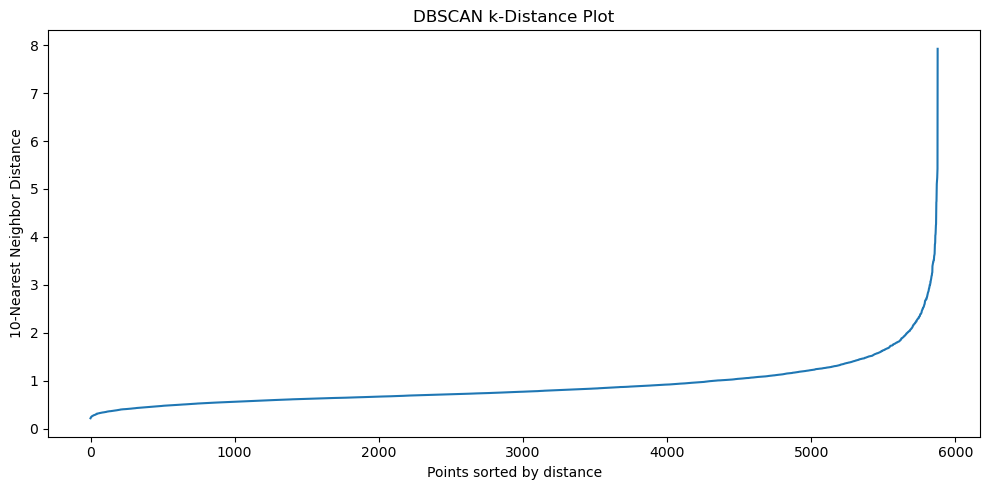

In [4]:
# Section 4 — Find DBSCAN eps
from sklearn.neighbors import NearestNeighbors

min_samples = 10

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors.fit(X)

distances, _ = neighbors.kneighbors(X)

k_distances = np.sort(
    distances[:, -1]
)

plt.figure(figsize=(10, 5))

plt.plot(k_distances)

plt.title("DBSCAN k-Distance Plot")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-Nearest Neighbor Distance")

plt.tight_layout()
plt.show()

In [5]:
# Section 5 — DBSCAN parameter search
eps_values = [1.5, 1.75, 2.0, 2.25, 2.5]

dbscan_results = []

for eps in eps_values:

    model = DBSCAN(
        eps=eps,
        min_samples=10
    )

    labels = model.fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_count = (labels == -1).sum()
    noise_pct = noise_count / len(labels) * 100

    if n_clusters >= 2:
        non_noise_mask = labels != -1

        silhouette = silhouette_score(
            X[non_noise_mask],
            labels[non_noise_mask]
        )

        calinski = calinski_harabasz_score(
            X[non_noise_mask],
            labels[non_noise_mask]
        )

        davies = davies_bouldin_score(
            X[non_noise_mask],
            labels[non_noise_mask]
        )
    else:
        silhouette = np.nan
        calinski = np.nan
        davies = np.nan

    dbscan_results.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_count": noise_count,
        "noise_percentage": noise_pct,
        "silhouette": silhouette,
        "calinski_harabasz": calinski,
        "davies_bouldin": davies
    })

dbscan_results_df = pd.DataFrame(dbscan_results)

dbscan_results_df.round(3)

,eps,clusters,noise_count,noise_percentage,silhouette,calinski_harabasz,davies_bouldin
0,1.50,2,250,4.253,0.316,2706.810,1.326
1,1.75,2,152,2.586,0.311,2658.822,1.350
2,2.00,2,111,1.888,0.309,2621.929,1.362
3,2.25,1,64,1.089,NaN,NaN,NaN
4,2.50,1,50,0.851,NaN,NaN,NaN


In [6]:
# Section 6 — Final DBSCAN
FINAL_EPS = 1.50
FINAL_MIN_SAMPLES = 10

final_dbscan = DBSCAN(
    eps=FINAL_EPS,
    min_samples=FINAL_MIN_SAMPLES
)

dbscan_labels = final_dbscan.fit_predict(X)

dbscan_df = ml_df[["Customer ID"]].copy()
dbscan_df["dbscan_cluster"] = dbscan_labels

print("Clusters:", sorted(set(dbscan_labels)))
print("Noise customers:", (dbscan_labels == -1).sum())

Clusters: [-1, 0, 1]
Noise customers: 250


In [7]:
dbscan_distribution = (
    dbscan_df["dbscan_cluster"]
    .value_counts()
    .sort_index()
)

dbscan_distribution

dbscan_cluster
-1     250
 0    3328
 1    2300
Name: count, dtype: int64

In [9]:
# Load raw customer features for profiling

RAW_FEATURES_PATH = (
    PROCESSED_DATA_DIR /
    "customer_features.parquet"
)

customer_features = pd.read_parquet(
    RAW_FEATURES_PATH
)

print("Customer features:", customer_features.shape)

Customer features: (5878, 16)


In [10]:
# Section 7 — Profile DBSCAN
dbscan_profile = customer_features.copy()

dbscan_profile["dbscan_cluster"] = dbscan_labels

dbscan_profile_features = [
    "recency_days",
    "frequency",
    "monetary",
    "average_order_value",
    "avg_items_per_order",
    "unique_products",
    "purchase_span_days",
    "return_order_share",
    "return_value_share",
    "has_return"
]

dbscan_profile_median = (
    dbscan_profile
    .groupby("dbscan_cluster")[dbscan_profile_features]
    .median()
    .round(2)
)

dbscan_profile_median

,recency_days,frequency,monetary,average_order_value,avg_items_per_order,unique_products,purchase_span_days,return_order_share,return_value_share,has_return
dbscan_cluster,,,,,,,,,,
-1,155.38,3.0,1634.01,378.10,182.12,15.0,186.96,0.31,0.21,1.0
0,183.11,2.0,465.78,231.19,133.94,29.0,48.93,0.00,0.00,0.0
1,51.08,6.0,2108.14,326.10,184.08,84.0,455.07,0.25,0.02,1.0


In [11]:
dbscan_profile_mean = (
    dbscan_profile
    .groupby("dbscan_cluster")[dbscan_profile_features]
    .mean()
    .round(2)
)

dbscan_profile_mean

,recency_days,frequency,monetary,average_order_value,avg_items_per_order,unique_products,purchase_span_days,return_order_share,return_value_share,has_return
dbscan_cluster,,,,,,,,,,
-1,227.59,16.21,19541.50,1525.18,1364.26,112.13,268.03,0.30,0.23,0.84
0,246.20,2.93,884.43,293.88,176.66,50.64,175.53,0.00,0.00,0.00
1,134.89,10.07,4150.45,393.37,228.76,124.08,415.57,0.27,0.03,1.00


In [12]:
# Next: compare K-Means vs DBSCAN
# Section 8 — K-Means vs DBSCAN

comparison = pd.DataFrame({
    "method": ["K-Means", "DBSCAN"],
    "clusters": [5, 2],
    "noise_points": [0, 250],
    "noise_percentage": [0, 250 / len(X) * 100],
    "silhouette": [0.260, 0.316],
    "davies_bouldin": [1.267, 1.326]
})

comparison.round(3)

,method,clusters,noise_points,noise_percentage,silhouette,davies_bouldin
0,K-Means,5,0,0.000,0.260,1.267
1,DBSCAN,2,250,4.253,0.316,1.326


In [13]:
# Section 9 — Gaussian Mixture Models
from sklearn.mixture import GaussianMixture

In [14]:
gmm_results = []

for n in range(2, 9):

    gmm = GaussianMixture(
        n_components=n,
        covariance_type="full",
        random_state=42,
        n_init=10
    )

    labels = gmm.fit_predict(X)

    gmm_results.append({
        "components": n,
        "bic": gmm.bic(X),
        "aic": gmm.aic(X),
        "silhouette": silhouette_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels)
    })

gmm_results_df = pd.DataFrame(gmm_results)

gmm_results_df.round(3)

,components,bic,aic,silhouette,davies_bouldin
0,2,-69748.026,-70622.971,0.302,1.423
1,3,-78969.051,-80284.808,0.260,1.546
2,4,-127862.461,-129619.030,0.194,1.590
3,5,-140411.069,-142608.450,0.124,2.202
4,6,-146461.929,-149100.123,0.099,2.896
5,7,-150434.148,-153513.154,0.094,2.948
6,8,-155709.746,-159229.564,0.073,2.226


In [15]:
# Section 10 — Final GMM
FINAL_COMPONENTS = 2

final_gmm = GaussianMixture(
    n_components=FINAL_COMPONENTS,
    covariance_type="full",
    random_state=42,
    n_init=10
)

gmm_labels = final_gmm.fit_predict(X)

print("GMM fitted successfully.")
print("Components:", FINAL_COMPONENTS)

GMM fitted successfully.
Components: 2


In [16]:
gmm_distribution = (
    pd.Series(gmm_labels)
    .value_counts()
    .sort_index()
)

gmm_distribution

0    3367
1    2511
Name: count, dtype: int64

In [17]:
gmm_profile = customer_features.copy()

gmm_profile["gmm_cluster"] = gmm_labels

gmm_profile_median = (
    gmm_profile
    .groupby("gmm_cluster")[dbscan_profile_features]
    .median()
    .round(2)
)

gmm_profile_median

,recency_days,frequency,monetary,average_order_value,avg_items_per_order,unique_products,purchase_span_days,return_order_share,return_value_share,has_return
gmm_cluster,,,,,,,,,,
0,181.08,2.0,469.13,232.07,134.0,29.0,49.10,0.00,0.00,0.0
1,54.86,6.0,2082.97,326.27,183.7,79.0,434.98,0.25,0.02,1.0


In [18]:
# Section 11 — Model Comparison
model_comparison = pd.DataFrame({
    "Model": [
        "K-Means",
        "DBSCAN",
        "GMM"
    ],
    "Clusters": [
        5,
        2,
        2
    ],
    "Noise": [
        0,
        250,
        0
    ],
    "Silhouette": [
        0.260,
        0.316,
        0.302
    ],
    "Davies-Bouldin": [
        1.267,
        1.326,
        1.423
    ]
})

model_comparison

,Model,Clusters,Noise,Silhouette,Davies-Bouldin
0,K-Means,5,0,0.260,1.267
1,DBSCAN,2,250,0.316,1.326
2,GMM,2,0,0.302,1.423


In [19]:
# Section 12 — Save Alternative Model Results

dbscan_output = ml_df[["Customer ID"]].copy()
dbscan_output["dbscan_cluster"] = dbscan_labels

gmm_output = ml_df[["Customer ID"]].copy()
gmm_output["gmm_cluster"] = gmm_labels

dbscan_output.to_parquet(
    PROCESSED_DATA_DIR / "customer_segments_dbscan.parquet",
    index=False
)

gmm_output.to_parquet(
    PROCESSED_DATA_DIR / "customer_segments_gmm.parquet",
    index=False
)

print("DBSCAN saved.")
print("GMM saved.")

DBSCAN saved.
GMM saved.
